In [4]:
!pip install transformers datasets pillow torch torchvision accelerate evaluate -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [33]:
# Ячейка 2: Импорт библиотек
import torch
import transformers
from transformers import pipeline, AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from datasets import load_dataset
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import evaluate
import numpy as np


print(f"Версия transformers: {transformers.__version__}")
print(f"PyTorch доступен: {torch.cuda.is_available()}")


Версия transformers: 4.56.0
PyTorch доступен: False


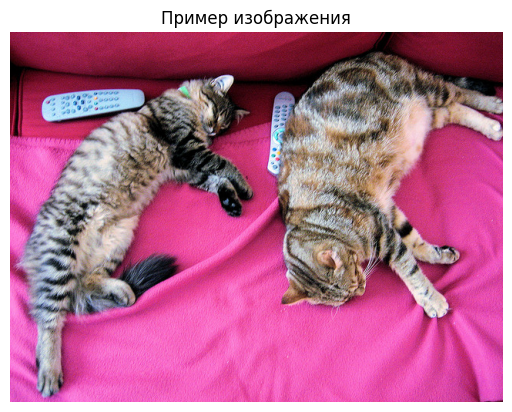

In [7]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
plt.imshow(image)
plt.axis('off')
plt.title("Пример изображения")
plt.show()

In [8]:
"""
## 2. Импорт модели - Pipeline API (самый простой способ)

Pipeline - это высокоуровневый интерфейс для работы с моделями
"""

# Создаем pipeline для классификации изображений
classifier = pipeline("image-classification", model="google/vit-base-patch16-224", device='mps')

# Применяем к изображению
results = classifier(image)

# Выводим результаты
print("Результаты классификации:")
for result in results:
    print(f"  {result['label']}: {result['score']:.4f}")


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 18157.16it/s]
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 15650.39it/s]
Device set to use mps


Результаты классификации:
  Egyptian cat: 0.9374
  tabby, tabby cat: 0.0384
  tiger cat: 0.0144
  lynx, catamount: 0.0033
  Siamese cat, Siamese: 0.0007


In [34]:
model_name = "google/vit-base-patch16-224"

# Загружаем процессор изображений и модель
image_processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

print(f"Модель загружена: {model.__class__.__name__}")
print(f"Количество классов: {model.config.num_labels}")

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 21732.15it/s]
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 17772.47it/s]


Модель загружена: ViTForImageClassification
Количество классов: 1000


In [11]:
"""
Применяем модель к изображению вручную
"""

# Препроцессинг
inputs = image_processor(images=image, return_tensors="pt")

# Инференс
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# Получаем предсказания
predicted_class_idx = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_idx]
probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]

print(f"Предсказанный класс: {predicted_label}")
print(f"Вероятность: {probabilities[predicted_class_idx]:.4f}")


Предсказанный класс: Egyptian cat
Вероятность: 0.9374


In [35]:
dataset = load_dataset("cifar10", split="test")

print(f"Размер датасета: {len(dataset)}")
print(f"Признаки датасета: {dataset.features}")
print(f"\nПример элемента:")
print(dataset[0])

Размер датасета: 10000
Признаки датасета: {'img': Image(mode=None, decode=True), 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

Пример элемента:
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x367CB2510>, 'label': 3}


In [36]:
dataset

Dataset({
    features: ['img', 'label'],
    num_rows: 10000
})

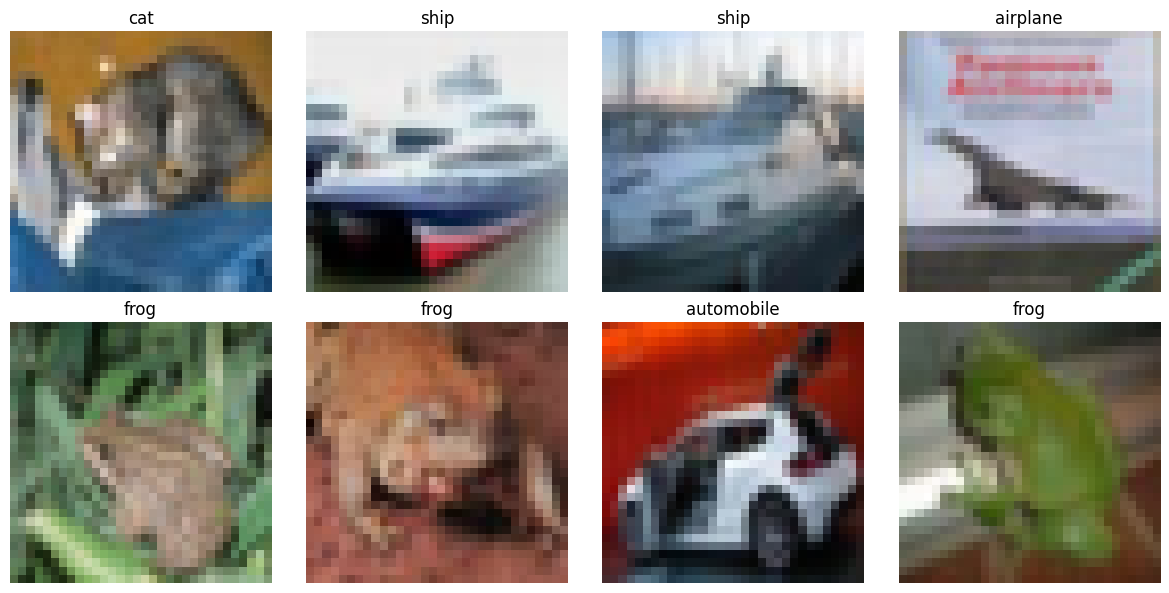

In [37]:
"""
Посмотрим на несколько примеров из датасета
"""

# Названия классов CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Визуализируем 8 случайных изображений
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    sample = dataset[i]
    ax.imshow(sample['img'])
    ax.set_title(f"{class_names[sample['label']]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


In [38]:
"""
Применяем модель ко всем изображениям
"""
test_dataset = dataset.select(range(100))

# Загружаем модель, обученную на ImageNet
zero_shot_classifier = pipeline(
    "image-classification", 
    model="microsoft/resnet-50",
    device="mps"
)


predictions = []
true_labels = []

for i, sample in enumerate(test_dataset):
    
    result = zero_shot_classifier(sample['img'])
    predictions.append(result[0]['label'])
    true_labels.append(class_names[sample['label']])

# Простая метрика точности (учитываем разницу в названиях классов)
def fuzzy_match(pred, true):
    """Нечеткое сравнение (ImageNet vs CIFAR-10 labels)"""
    pred_lower = pred.lower()
    true_lower = true.lower()
    return true_lower in pred_lower or pred_lower in true_lower

correct = sum(fuzzy_match(p, t) for p, t in zip(predictions, true_labels))
accuracy = correct / len(predictions)

print(f"Zero-shot точность: {accuracy:.2%}")
print(f"\nПримеры предсказаний:")
for i in range(5):
    print(f"  Истинный: {true_labels[i]:12} | Предсказан: {predictions[i]}")

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 23831.27it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use mps


Zero-shot точность: 10.00%

Примеры предсказаний:
  Истинный: cat          | Предсказан: fox squirrel, eastern fox squirrel, Sciurus niger
  Истинный: ship         | Предсказан: amphibian, amphibious vehicle
  Истинный: ship         | Предсказан: amphibian, amphibious vehicle
  Истинный: airplane     | Предсказан: moving van
  Истинный: frog         | Предсказан: tailed frog, bell toad, ribbed toad, tailed toad, Ascaphus trui


In [40]:
from datasets import load_dataset

# Загружаем train и test splits
train_ds = load_dataset("cifar10", split="train[:5000]")  # Используем подмножество
test_ds = load_dataset("cifar10", split="test[:1000]")

print(f"Train размер: {len(train_ds)}")
print(f"Test размер: {len(test_ds)}")

# Загружаем модель для файн-тюнинга
model_checkpoint = "microsoft/resnet-18"  # Легкая модель для быстрого обучения
image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

Train размер: 5000
Test размер: 1000


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 29330.80it/s]


In [ ]:
def transform(examples):
    """Применяем image processor к батчу изображений"""
    inputs = image_processor(examples['img'], return_tensors='pt')
    inputs['label'] = examples['label']
    return inputs

# Применяем трансформацию
train_ds = train_ds.with_transform(transform)
test_ds = test_ds.with_transform(transform)


In [55]:
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=10,
    id2label={i: label for i, label in enumerate(class_names)},
    label2id={label: i for i, label in enumerate(class_names)},
    ignore_mismatched_sizes=True  # Переинициализируем голову классификации
)

# Загружаем модель с правильным количеством классов
print(f"Модель настроена на {model.config.num_labels} классов")

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([10, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель настроена на 10 классов


In [56]:
"""
Определяем метрики для оценки
"""
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """Вычисляет метрики на валидации"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    
    return accuracy_metric.compute(predictions=predictions, references=labels)

In [57]:
"""
Создаем TrainingArguments с параметрами обучения
"""

training_args = TrainingArguments(
    output_dir="./cifar10-resnet18",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    push_to_hub=False,  # Можно загрузить на HF Hub
    remove_unused_columns=False,
)

print(f"  Эпох: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")

  Эпох: 3
  Batch size: 8
  Learning rate: 5e-05


In [59]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    tokenizer=image_processor,  # Для сохранения вместе с моделью
)

#train_result = trainer.train()

print("\n✅ Обучение завершено!")
print(f"Время обучения: {train_result.metrics['train_runtime']:.2f} сек")


✅ Обучение завершено!
Время обучения: 123.43 сек


/var/folders/_k/fwtz838s6rz39n6gg5c4jcrc0000gn/T/ipykernel_3120/1550886482.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [60]:
test_results = trainer.evaluate()

print("📊 Результаты на тестовой выборке:")
print(f"  Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"  Loss: {test_results['eval_loss']:.4f}")

/Users/timmiakov/Dev/hse-ml-course/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


📊 Результаты на тестовой выборке:
  Accuracy: 0.1050
  Loss: 2.4993


In [54]:
test_results = trainer.evaluate()

print("📊 Результаты на тестовой выборке:")
print(f"  Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"  Loss: {test_results['eval_loss']:.4f}")

/Users/timmiakov/Dev/hse-ml-course/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


📊 Результаты на тестовой выборке:
  Accuracy: 0.8780
  Loss: 0.3433


In [ ]:
# Загружаем обученную модель
trained_pipeline = pipeline(
    "image-classification",
    model="./my_cifar10_model"
)

# Тестируем на случайном изображении
test_idx = 42
test_sample = dataset[test_idx]

result = trained_pipeline(test_sample['img'])

# Визуализируем результат
plt.imshow(test_sample['img'])
plt.axis('off')
plt.title(f"True: {class_names[test_sample['label']]}\nPredicted: {result[0]['label']} ({result[0]['score']:.2%})")
plt.show()

print("\nTop-3 предсказания:")
for r in result[:3]:
    print(f"  {r['label']}: {r['score']:.4f}")